<a href="https://colab.research.google.com/github/brunoss-on/scimlga2026/blob/main/lab03_TreinoRedeRepresentadoraModelos/treino_rede_representadora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Environment setup

import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    ENV = "colab"
    print("Running on Google Colab")
else:
    ENV = "local"
    print("Running locally")

Running on Google Colab


In [2]:
if ENV == "colab":

  print("Install dependencies")
  !pip install deepwave==0.0.10

  # Library Imports
  import os
  import math
  import torch
  import torch.nn as nn
  import numpy as np
  import scipy
  import matplotlib.pyplot as plt
  from torchsummary import summary
  import cv2
  %matplotlib inline

  import deepwave
  from deepwave import scalar

else:
   import os
   import math
   import torch
   import torch.nn as nn
   import numpy as np
   import scipy
   import matplotlib.pyplot as plt
   from torchsummary import summary
   import cv2
   %matplotlib inline

   import deepwave
   from deepwave import scalar

Install dependencies
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 2.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 10.7 MB/s eta 0:00:00
  Created wheel for deepwave: filename=deepwave-0.0.10-py3-none-any.whl size=45139 sha256=b7643c1b6bab1c147a76baa9a2022bf1d88f6af232a4f751e43cff4e01f694d7
  Stored in directory: /root/.cache/pip/wheels/93/05/32/5eff15f407b7315abf53465751d83f1009dc2afae4631d6ee3
Successfully built deepwave


In [6]:
# Device Configuration: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [11]:
# Set up the workspace

REPO_DIR = "/content/scimlga2026"

if not os.path.exists(REPO_DIR):
    print("Cloning the SciMLGA 2026 course repository from GitHub...")
    !git clone https://github.com/brunoss-on/scimlga2026.git {REPO_DIR}
    print("Repository successfully cloned!")
else:
    print("Repository already available. Skipping clone.")

Cloning the SciMLGA 2026 course repository from GitHub...
Cloning into '/content/scimlga2026'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 94 (delta 4), reused 12 (delta 1), pack-reused 74 (from 1)
Receiving objects: 100% (94/94), 79.94 MiB | 19.41 MiB/s, done.
Resolving deltas: 100% (30/30), done.
Repository successfully cloned!


In [13]:
WORK_DIR = os.path.join(REPO_DIR, "lab03_TreinoRedeRepresentadoraModelos")
os.chdir(WORK_DIR)
print("Current directory:", os.getcwd())
print("Current contents:", os.listdir())

Current directory: /content/scimlga2026/lab03_TreinoRedeRepresentadoraModelos
Current contents: ['treino_rede_representadora.ipynb', 'Teste02', 'Teste03', 'Teste01', 'modelo_BP.npy']


In [14]:
#importa o modelo de velocidades que vai ser usado para gerar o dado "adquirido" e que é alvo da inversão
model=np.load('./modelo_BP.npy')

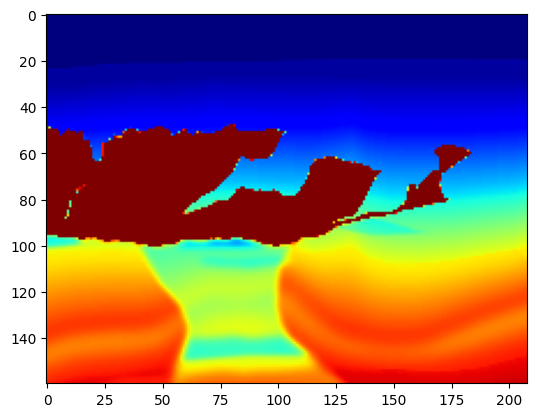

In [15]:
model_npy=cv2.resize(model,(208,160)).T
plt.imshow(model_npy.T, cmap='jet')

In [16]:
#configurações da aquisição geofísica a serem usadas no deepwave
dx = 10.0 # 10m de grid na vertical e horizontal
dt = 0.002 # 2ms de intervalo de registro dos tiros
nz = 160
ny = 208
nt = 960
peak_freq = 8
peak_source_time = 1/peak_freq
peak_time = 1.0 / peak_freq

# desenho da aquisição, 1 receptor em cada cela do modelo, receptores com posições fixas, o que se move é a fonte
num_dims = 2
num_shots = 20
num_sources_per_shot = 1
num_receivers_per_shot = 208
source_spacing = 10 #250*10m=2500m
receiver_spacing = 1#1*10m
first_source=4
first_receiver=0
source_depth=1
receiver_depth=1

model =torch.ones(ny, nz) * model_npy
model_prop=model.to(device)

/tmp/ipykernel_5803/888287264.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  model =torch.ones(ny, nz) * model_npy


In [20]:
# source_locations
source_locations = torch.zeros(num_shots,num_sources_per_shot,2,
                               dtype=torch.long, device=device)
source_locations[..., 1] = source_depth
source_locations[:, 0, 0] = torch.arange(num_shots)*source_spacing+ first_source

# receiver_locations
receiver_locations = torch.zeros(num_shots,num_receivers_per_shot, 2,
                                 dtype=torch.long, device=device)
receiver_locations[..., 1] = receiver_depth
receiver_locations[:, :, 0] = (
    (torch.arange(num_receivers_per_shot)*receiver_spacing + first_receiver)
    .repeat(num_shots, 1)
)

# source_amplitudes
source_amplitudes = (
    deepwave.wavelets.ricker(peak_freq, nt, dt,peak_time)
    .repeat(num_shots,num_sources_per_shot, 1)
    .to(device)
)

In [18]:
# simula a aquisição
out = scalar(model_prop,dx,dt,source_amplitudes=source_amplitudes,
             source_locations=source_locations,
             receiver_locations=receiver_locations,
             accuracy=8,
             pml_freq=peak_freq,pml_width=[50,50,50,50])
receiver_amplitudes=out[-1]

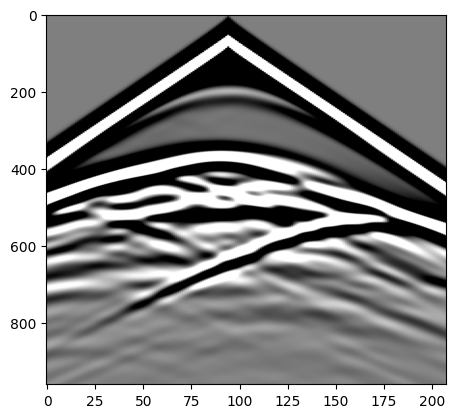

In [21]:
vmin, vmax = torch.quantile(receiver_amplitudes[0],
                            torch.tensor([0.05, 0.95]).to(device))
plt.imshow(receiver_amplitudes[9,:,:].cpu().T*-1, cmap='gray',
             vmin=-vmax/5,vmax=vmax/5,aspect=0.2)

In [22]:
# Construcao da rede neural
class EncoderBlock(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.encoder_block = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding="same", bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding="same", bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2),padding=0)
        )

    def forward(self, x):
        return self.encoder_block(x)

class DecoderBlock(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.decoder_block = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding="same", bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding="same", bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(inplace=True),
        )

    def forward(self, x):
        return self.decoder_block(x)


class FinalConv(nn.Module):
    """(reduce final feature maps to one channel)"""

    def __init__(self, in_channels, out_channels=1):
        super().__init__()
        self.final_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, padding="same", bias=False),

            nn.Sigmoid()
        )

    def forward(self, x):
        return self.final_conv(x)


class TestEncoderDecoder(nn.Module):
    def __init__(self, n_channels,filters):
        super(TestEncoderDecoder, self).__init__()
        self.n_channels = n_channels
        self.filters = filters

        self.encoder_1 = EncoderBlock(n_channels, filters)
        self.encoder_2 = EncoderBlock(filters, filters*2)
        self.encoder_3 = EncoderBlock(filters*2, filters*4)
        self.encoder_4 = EncoderBlock(filters*4, filters*8)

        self.decoder_1 = DecoderBlock(filters*8, filters*8)
        self.decoder_2 = DecoderBlock(filters*8, filters*4)
        self.decoder_3 = DecoderBlock(filters*4, filters*2)
        self.decoder_4 = DecoderBlock(filters*2, filters*1)

        self.outc = FinalConv(filters)

    def forward(self, x):
        x1 = self.encoder_1(x)
        x2 = self.encoder_2(x1)
        x3 = self.encoder_3(x2)
        x4 = self.encoder_4(x3)

        x6 = self.decoder_1(x4)

        x7 = self.decoder_2(x6)
        x8 = self.decoder_3(x7)
        x9 = self.decoder_4(x8)

        logits = self.outc(x9)

        return logits

In [23]:
n_filters=36
net=TestEncoderDecoder(num_shots,filters=n_filters).to(device)
summary(net,(20,208,160))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 36, 208, 160]           6,480
       BatchNorm2d-2         [-1, 36, 208, 160]              72
         LeakyReLU-3         [-1, 36, 208, 160]               0
            Conv2d-4         [-1, 36, 208, 160]          11,664
       BatchNorm2d-5         [-1, 36, 208, 160]              72
         LeakyReLU-6         [-1, 36, 208, 160]               0
         MaxPool2d-7          [-1, 36, 104, 80]               0
      EncoderBlock-8          [-1, 36, 104, 80]               0
            Conv2d-9          [-1, 72, 104, 80]          23,328
      BatchNorm2d-10          [-1, 72, 104, 80]             144
        LeakyReLU-11          [-1, 72, 104, 80]               0
           Conv2d-12          [-1, 72, 104, 80]          46,656
      BatchNorm2d-13          [-1, 72, 104, 80]             144
        LeakyReLU-14          [-1, 72, 

In [24]:
#DEFININDO O DADO DE ENTRADA DA REDE DENTRO DO MODELO DE USO DE TIROS COMO ENTRADA
# o que entra na rede é reamostrado para ficar com as mesmas dimensões da saída
x=torch.Tensor(torch.reshape(receiver_amplitudes,(1,num_shots,num_receivers_per_shot,nt))[:,:,:,0:1600:6]).to(device)
print(x.shape)
# NOTA: OS SISMOGRAMAS DE REFERENCIA PARA CALCULO DA LOSS  NÃO SAO OS MESMOS. ELES NÃO FORAM REAMOSTRADOS, apenas vão para o device e ganham uma dimensão extra
true_seism=torch.reshape(receiver_amplitudes,(1,num_shots,num_receivers_per_shot,nt)).to(device)

torch.Size([1, 20, 208, 160])


In [25]:
batch_size=5 # batch de tiros para cálculo do FWI- se estourar memória, reduzir esse valor
num_batch=int(num_shots/batch_size)

/tmp/ipykernel_5803/457650115.py:47: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  metricas[1,epoch-1]=L2_model(yhat[:,:],model[:,:].to(device))


Epoca: 1 Erro dado: 0.3950132057070732 Erro modelo: 1393972.5
Epoca: 2 Erro dado: 0.2857351452112198 Erro modelo: 1199132.75
Epoca: 3 Erro dado: 0.2631490156054497 Erro modelo: 985414.4375
Epoca: 4 Erro dado: 0.24802503734827042 Erro modelo: 800336.375
Epoca: 5 Erro dado: 0.23466020822525024 Erro modelo: 734046.875
Epoca: 6 Erro dado: 0.22366562113165855 Erro modelo: 575948.1875
Epoca: 7 Erro dado: 0.21305280923843384 Erro modelo: 545753.5
Epoca: 8 Erro dado: 0.2029285542666912 Erro modelo: 507824.9375
Epoca: 9 Erro dado: 0.19140583649277687 Erro modelo: 488313.40625
Epoca: 10 Erro dado: 0.1824774481356144 Erro modelo: 457073.34375
Epoca: 11 Erro dado: 0.17355776578187943 Erro modelo: 456280.3125
Epoca: 12 Erro dado: 0.1659318543970585 Erro modelo: 454422.4375
Epoca: 13 Erro dado: 0.15842119604349136 Erro modelo: 461996.625
Epoca: 14 Erro dado: 0.14983530715107918 Erro modelo: 468342.75
Epoca: 15 Erro dado: 0.14244044944643974 Erro modelo: 486647.3125
Epoca: 16 Erro dado: 0.13738311827

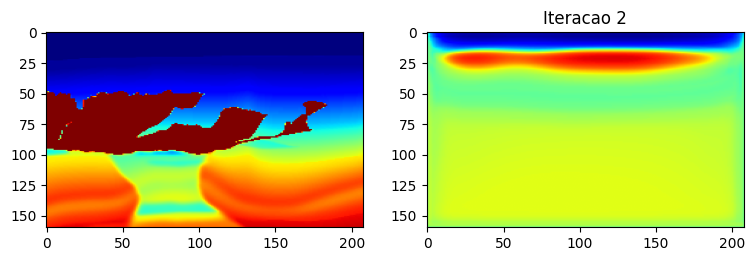

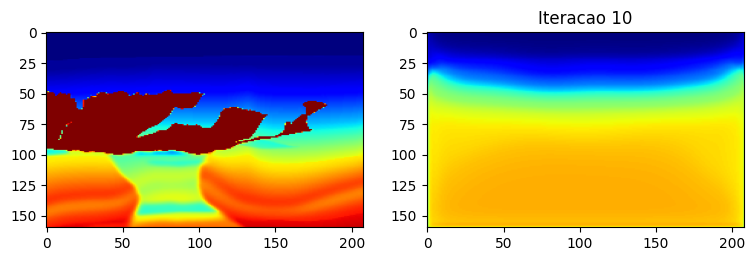

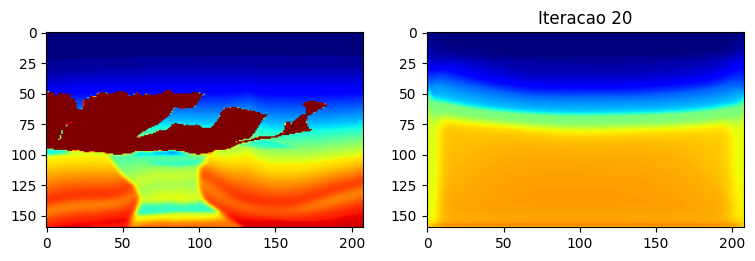

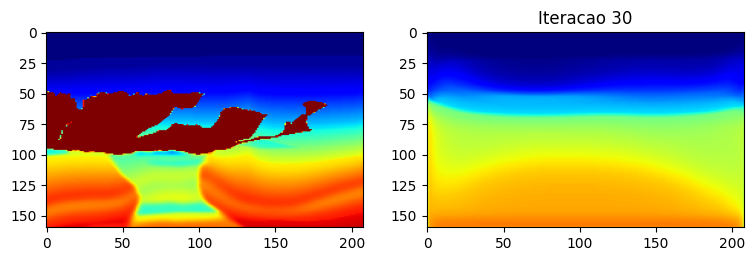

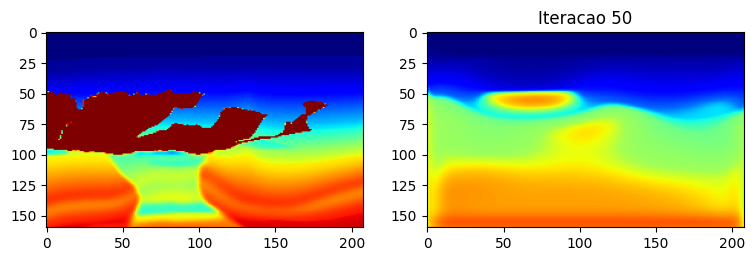

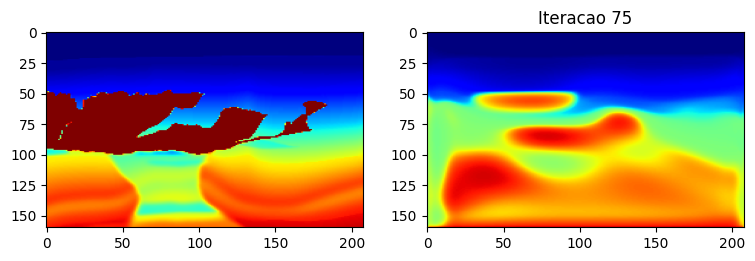

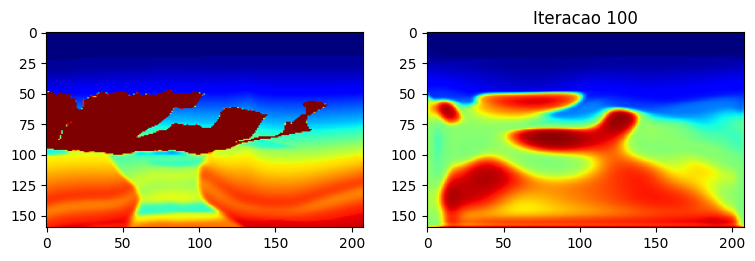

In [26]:
prefixo='BP_t1_'
optimizer = torch.optim.Adam(net.parameters(),lr=1e-3)
criterion = nn.L1Loss()
epochs=101
check_points=[2,10,20,30,50,75,100]
metricas=np.zeros((2,epochs))
L2_model=nn.MSELoss(reduction='mean')
#Begin training
for epoch in range(1, epochs+1):
    net.train()
    epoch_loss = 0

    teste=np.arange(num_shots)
    np.random.shuffle(teste)
    ind_vec=np.reshape(teste,(num_batch,batch_size))
    for bc in range(num_batch):
        optimizer.zero_grad()
        yhat = net(x)#modelo de velocidade previsto pela rede, fora da escala
        yhat=torch.squeeze(yhat)[:,:]
        yhat=yhat*(torch.max(model)-torch.min(model)) + torch.min(model)# como a última camada da rede usa uma
        #função de ativação sigmoide, é preciso colocar os valores da imagem de saída para os valores reais de velocidade

        yhat=yhat.type(torch.float32)


        #modelagem do dado que irá servir de entrada para cálculo da loss do FWI
        out = scalar(yhat,dx,dt,source_amplitudes=source_amplitudes[ind_vec[bc]],
                 source_locations=source_locations[ind_vec[bc]],
                 receiver_locations=receiver_locations[ind_vec[bc]],
                 accuracy=8,
                 pml_freq=peak_freq,pml_width=[50,50,50,50])
        receiver_amplitudes_hat=out[-1]


        #receiver_amplitudes_hat -= receiver_amplitudes_homo[ind_vec[bc]] # elimina a onda direta
        xhat=torch.squeeze(receiver_amplitudes_hat)
        xhat=torch.unsqueeze(xhat,0)
        loss = criterion(xhat,torch.unsqueeze(torch.squeeze(true_seism)[ind_vec[bc]],0)) #loss entre tiros "reais" e simuluados


        loss.backward()# backpropagation, passando pela parte física do problema (FWI) e injetando o gradiente da parte física na rede neural
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss=epoch_loss/num_batch
    metricas[0,epoch-1]=epoch_loss
    metricas[1,epoch-1]=L2_model(yhat[:,:],model[:,:].to(device))
    print('Epoca:',epoch, 'Erro dado:', epoch_loss,'Erro modelo:',metricas[1,epoch-1])
    if epoch in check_points:
        fig,ax =plt.subplots(nrows=1,ncols=2,figsize=(9,5))
        ax[0].imshow(model[:,:].T,aspect=0.8,cmap='jet',vmin=1500,vmax=4500)
        ax[1].imshow(yhat.cpu().detach().numpy()[:,:].T,aspect=0.8,cmap='jet',vmin=1500,vmax=4500)
        ax[1].set_title('Iteracao {}'.format(epoch))
        fig.savefig('./Teste01/'+prefixo+'_{}.png'.format(epoch), format='png')

Agora vamos testar o que acontece quando a rede recebe ruído aleatório como entrada

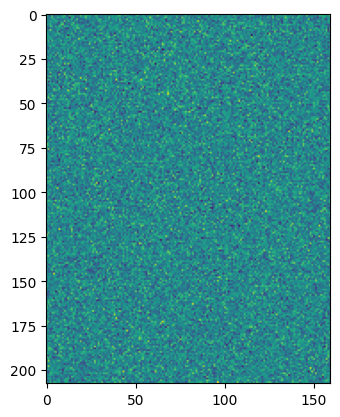

In [27]:
n_filters=36
net=TestEncoderDecoder(num_shots,filters=n_filters).to(device)
xx = torch.randn_like(x) #geração do ruído para entrada, a arquitetura se mantém a mesma
plt.imshow(xx.cpu().numpy()[0,0,:,:])

Epoca: 1 Erro dado: 0.41031456738710403 Erro modelo: 1524027.0
Epoca: 2 Erro dado: 0.28550416976213455 Erro modelo: 1358287.5
Epoca: 3 Erro dado: 0.26225364208221436 Erro modelo: 1142182.875
Epoca: 4 Erro dado: 0.25101570412516594 Erro modelo: 1014331.5
Epoca: 5 Erro dado: 0.24313706532120705 Erro modelo: 905813.6875
Epoca: 6 Erro dado: 0.238575991243124 Erro modelo: 840049.875
Epoca: 7 Erro dado: 0.23262417688965797 Erro modelo: 653590.1875
Epoca: 8 Erro dado: 0.21002644672989845 Erro modelo: 600453.125
Epoca: 9 Erro dado: 0.19368403404951096 Erro modelo: 534881.75
Epoca: 10 Erro dado: 0.18288103863596916 Erro modelo: 581157.5
Epoca: 11 Erro dado: 0.1721152700483799 Erro modelo: 566683.4375
Epoca: 12 Erro dado: 0.16255874559283257 Erro modelo: 534491.4375
Epoca: 13 Erro dado: 0.1497580073773861 Erro modelo: 553681.8125
Epoca: 14 Erro dado: 0.14234508574008942 Erro modelo: 546831.25
Epoca: 15 Erro dado: 0.1320452205836773 Erro modelo: 476752.25
Epoca: 16 Erro dado: 0.13069519959390163 

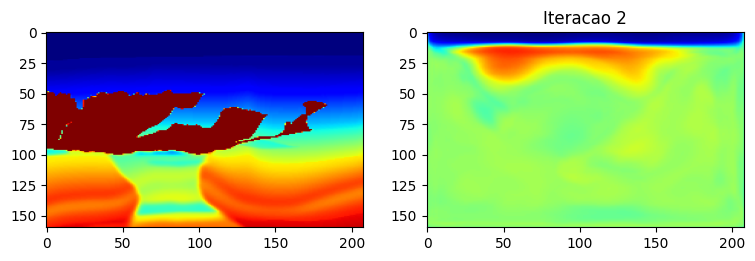

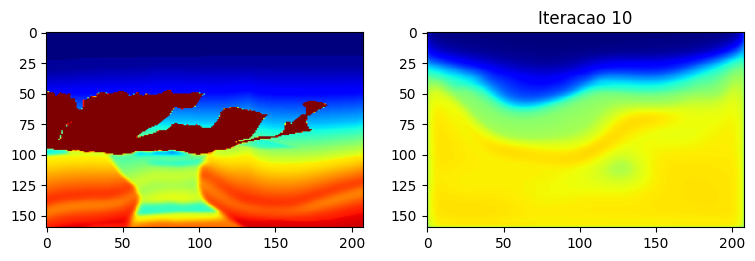

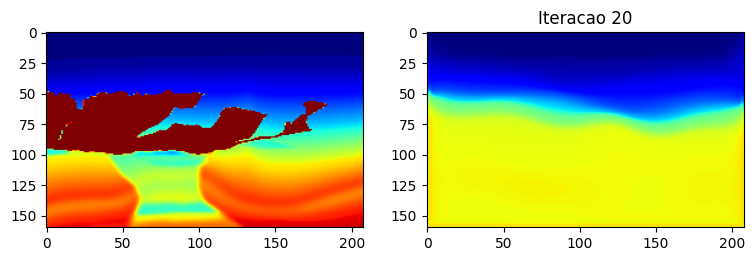

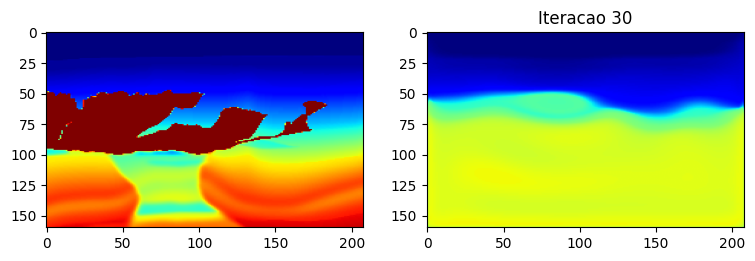

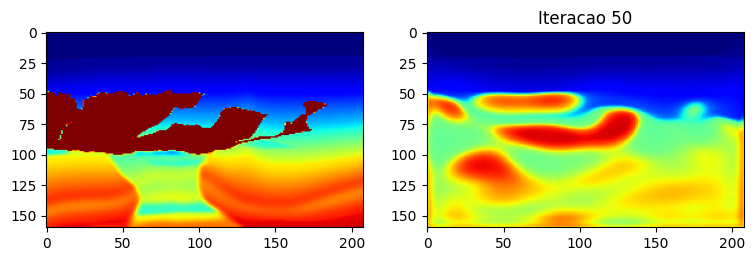

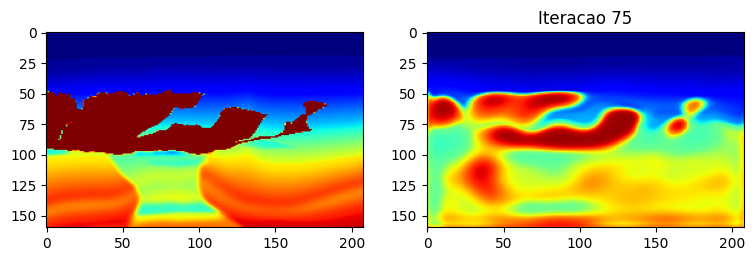

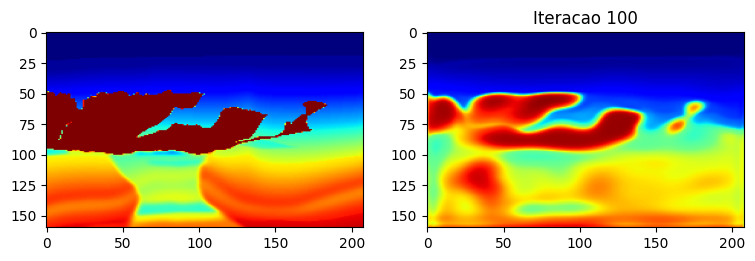

In [28]:
prefixo='BP_t2_'
optimizer = torch.optim.Adam(net.parameters(),lr=1e-3)
criterion = nn.L1Loss()
epochs=101
check_points=[2,10,20,30,50,75,100]
metricas=np.zeros((2,epochs))
L2_model=nn.MSELoss(reduction='mean')
#Begin training
for epoch in range(1, epochs+1):
    net.train()
    epoch_loss = 0

    teste=np.arange(num_shots)
    np.random.shuffle(teste)
    ind_vec=np.reshape(teste,(num_batch,batch_size))
    for bc in range(num_batch):
        optimizer.zero_grad()
        yhat = net(xx)#a entrada muda aqui, e passa a ser o ruído aleatório
        yhat=torch.squeeze(yhat)[:,:]
        yhat=yhat*(torch.max(model)-torch.min(model)) + torch.min(model)# como a última camada da rede usa uma

        #função de ativação sigmoide, é preciso colocar os valores da imagem de saída para os valores reais de velocidade
        yhat=yhat.type(torch.float32)


        #modelagem do dado que irá servir de entrada para cálculo da loss do FWI
        out = scalar(yhat,dx,dt,source_amplitudes=source_amplitudes[ind_vec[bc]],
                 source_locations=source_locations[ind_vec[bc]],
                 receiver_locations=receiver_locations[ind_vec[bc]],
                 accuracy=8,
                 pml_freq=peak_freq,pml_width=[50,50,50,50])
        receiver_amplitudes_hat=out[-1]


        #receiver_amplitudes_hat -= receiver_amplitudes_homo[ind_vec[bc]] # elimina a onda direta
        xhat=torch.squeeze(receiver_amplitudes_hat)
        xhat=torch.unsqueeze(xhat,0)
        loss = criterion(xhat,torch.unsqueeze(torch.squeeze(true_seism)[ind_vec[bc]],0)) #loss entre tiros "reais" e simluados


        loss.backward()# backpropagation, passando pela parte física do problema (FWI) e injetando o gradiente da parte física na rede neural
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss=epoch_loss/num_batch
    metricas[0,epoch-1]=epoch_loss
    metricas[1,epoch-1]=L2_model(yhat[:,:],model[:,:].to(device))
    print('Epoca:',epoch, 'Erro dado:', epoch_loss,'Erro modelo:',metricas[1,epoch-1])
    if epoch in check_points:
        fig,ax =plt.subplots(nrows=1,ncols=2,figsize=(9,5))
        ax[0].imshow(model[:,:].T,aspect=0.8,cmap='jet',vmin=1500,vmax=4500)
        ax[1].imshow(yhat.cpu().detach().numpy()[:,:].T,aspect=0.8,cmap='jet',vmin=1500,vmax=4500)
        ax[1].set_title('Iteracao {}'.format(epoch))
        fig.savefig('./Teste02/'+prefixo+'_{}.png'.format(epoch), format='png')

Já que a entrada não é usada como informação útil, que tal montar uma arquitetura apenas com o decoder?

In [29]:
class DecoderBlock(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.decoder_block = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding="same", bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding="same", bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(inplace=True),
        )

    def forward(self, x):
        return self.decoder_block(x)


class FinalConv(nn.Module):
    """(reduce final feature maps to one channel)"""

    def __init__(self, in_channels, out_channels=1):
        super().__init__()
        self.final_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, padding="same", bias=False),

            nn.Sigmoid()
        )

    def forward(self, x):
        return self.final_conv(x)


class TestOnlyDecoder(nn.Module):
    def __init__(self, n_channels,filters):
        super(TestOnlyDecoder, self).__init__()
        self.n_channels = n_channels
        self.filters = filters

        self.decoder_1 = DecoderBlock(1, filters*8)# 1 canal para acomodar a entrada compacta
        self.decoder_2 = DecoderBlock(filters*8, filters*4)
        self.decoder_3 = DecoderBlock(filters*4, filters*2)
        self.decoder_4 = DecoderBlock(filters*2, filters*1)

        self.outc = FinalConv(filters)

    def forward(self, x):

        x6 = self.decoder_1(x)
        x7 = self.decoder_2(x6)
        x8 = self.decoder_3(x7)
        x9 = self.decoder_4(x8)

        logits = self.outc(x9)

        return logits

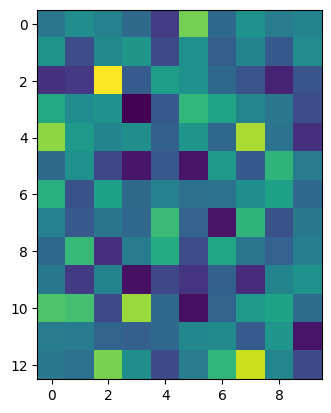

In [30]:
n_filters=36
net=TestOnlyDecoder(1,filters=n_filters).to(device)
xxx = torch.randn(1, 1, 13, 10).to(device) #imagem aleatória do tamanho do vetor latente, mas com apenas 1 canal(feature map), repara que o self.decoder_1 recebe 1 canal
plt.imshow(xxx.cpu().numpy()[0,0,:,:])


Epoca: 1 Erro dado: 0.4242628514766693 Erro modelo: 1446093.25
Epoca: 2 Erro dado: 0.30589040368795395 Erro modelo: 1432681.75
Epoca: 3 Erro dado: 0.28468891978263855 Erro modelo: 1285666.0
Epoca: 4 Erro dado: 0.2691238597035408 Erro modelo: 1241944.375
Epoca: 5 Erro dado: 0.261594295501709 Erro modelo: 1165844.625
Epoca: 6 Erro dado: 0.2522728778421879 Erro modelo: 1031564.5625
Epoca: 7 Erro dado: 0.2421623095870018 Erro modelo: 913119.0
Epoca: 8 Erro dado: 0.22962435334920883 Erro modelo: 877425.8125
Epoca: 9 Erro dado: 0.22243130579590797 Erro modelo: 791350.1875
Epoca: 10 Erro dado: 0.22006407380104065 Erro modelo: 787279.5625
Epoca: 11 Erro dado: 0.2085387520492077 Erro modelo: 713004.0625
Epoca: 12 Erro dado: 0.19638172164559364 Erro modelo: 655430.9375
Epoca: 13 Erro dado: 0.1860024817287922 Erro modelo: 592736.0
Epoca: 14 Erro dado: 0.1787618063390255 Erro modelo: 585203.9375
Epoca: 15 Erro dado: 0.17118683084845543 Erro modelo: 546371.8125
Epoca: 16 Erro dado: 0.16220450401306

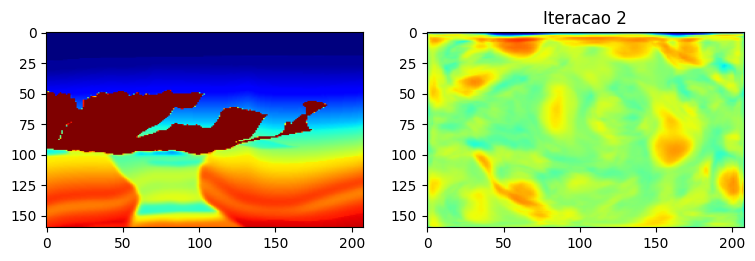

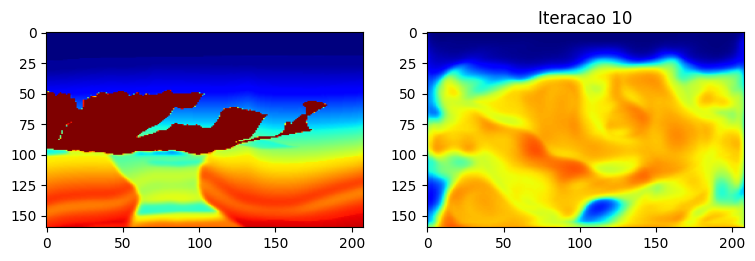

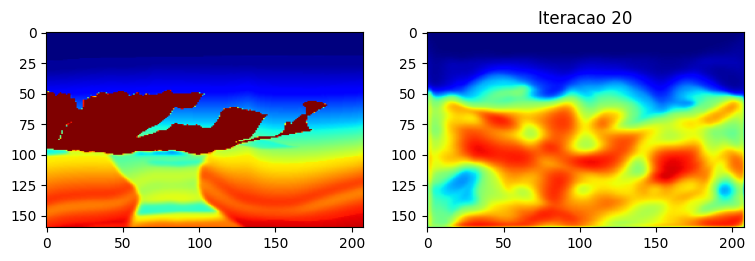

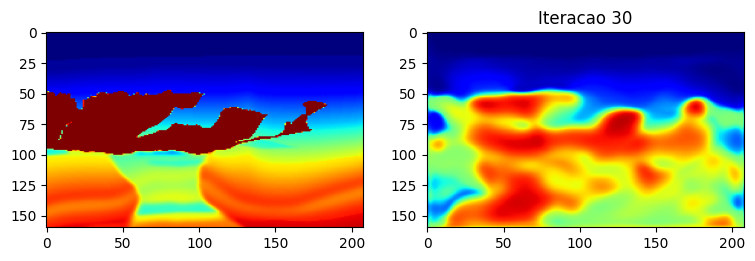

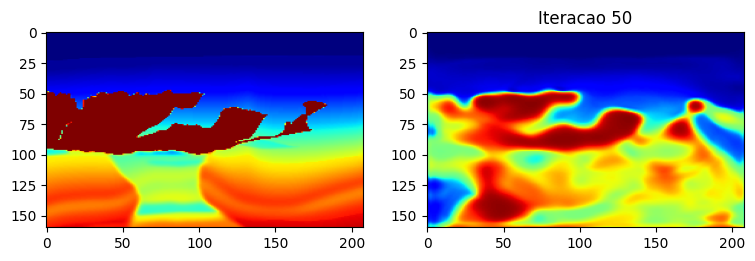

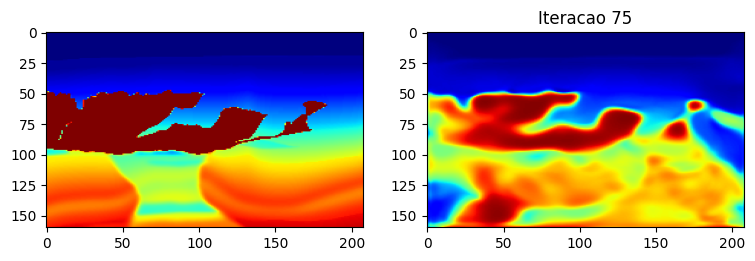

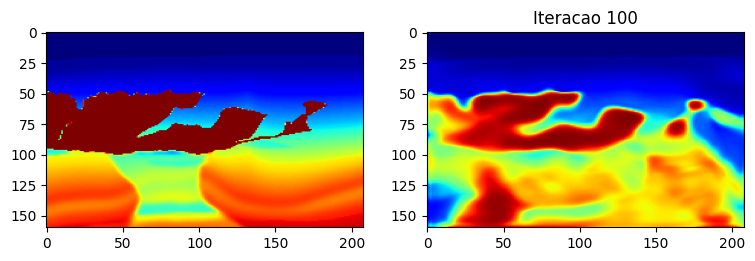

In [31]:
prefixo='BP_t3_'
optimizer = torch.optim.Adam(net.parameters(),lr=1e-3)
criterion = nn.L1Loss()
epochs=101
check_points=[2,10,20,30,50,75,100]
metricas=np.zeros((2,epochs))
L2_model=nn.MSELoss(reduction='mean')
#Begin training
for epoch in range(1, epochs+1):
    net.train()
    epoch_loss = 0

    teste=np.arange(num_shots)
    np.random.shuffle(teste)
    ind_vec=np.reshape(teste,(num_batch,batch_size))
    for bc in range(num_batch):
        optimizer.zero_grad()
        yhat = net(xxx)# tensor apenas com ruídos e nas dimensões do espaço latente e apenas um canal
        yhat=torch.squeeze(yhat)[:,:]
        yhat=yhat*(torch.max(model)-torch.min(model)) + torch.min(model)# como a última camada da rede usa uma

        #função de ativação sigmoide, é preciso colocar os valores da imagem de saída para os valores reais de velocidade
        yhat=yhat.type(torch.float32)


        #modelagem do dado que irá servir de entrada para cálculo da loss do FWI
        out = scalar(yhat,dx,dt,source_amplitudes=source_amplitudes[ind_vec[bc]],
                 source_locations=source_locations[ind_vec[bc]],
                 receiver_locations=receiver_locations[ind_vec[bc]],
                 accuracy=8,
                 pml_freq=peak_freq,pml_width=[50,50,50,50])
        receiver_amplitudes_hat=out[-1]


        #receiver_amplitudes_hat -= receiver_amplitudes_homo[ind_vec[bc]] # elimina a onda direta
        xhat=torch.squeeze(receiver_amplitudes_hat)
        xhat=torch.unsqueeze(xhat,0)
        loss = criterion(xhat,torch.unsqueeze(torch.squeeze(true_seism)[ind_vec[bc]],0)) #loss entre tiros "reais" e simluados


        loss.backward()# backpropagation, passando pela parte física do problema (FWI) e injetando o gradiente da parte física na rede neural
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss=epoch_loss/num_batch
    metricas[0,epoch-1]=epoch_loss
    metricas[1,epoch-1]=L2_model(yhat[:,:],model[:,:].to(device))
    print('Epoca:',epoch, 'Erro dado:', epoch_loss,'Erro modelo:',metricas[1,epoch-1])
    if epoch in check_points:
        fig,ax =plt.subplots(nrows=1,ncols=2,figsize=(9,5))
        ax[0].imshow(model[:,:].T,aspect=0.8,cmap='jet',vmin=1500,vmax=4500)
        ax[1].imshow(yhat.cpu().detach().numpy()[:,:].T,aspect=0.8,cmap='jet',vmin=1500,vmax=4500)
        ax[1].set_title('Iteracao {}'.format(epoch))
        fig.savefig('./Teste03/'+prefixo+'_{}.png'.format(epoch), format='png')